# Tensor Decompositions

Multi-dimensional arrays — **tensors** — arise throughout science and engineering: video is a 3-way
array (height × width × frames), a recommendation dataset is a 3-way array (users × items × contexts),
and quantum many-body states live in exponentially large tensor product spaces. Tensor decompositions
compress, denoise, and reveal latent structure by expressing a high-order array as a compact combination
of lower-dimensional factors.

## Topics Covered
1. **Multilinear algebra** — mode-$n$ unfolding (matricization), mode-$n$ product, tensor norms
2. **CP / PARAFAC** — rank-1 sum, Khatri-Rao product, ALS algorithm, uniqueness
3. **Tucker decomposition** — HOSVD, Higher-Order Orthogonal Iteration (HOOI), multilinear rank
4. **Tensor Train (TT / MPS)** — TT-SVD algorithm, bond dimensions, TT contraction
5. **Application** — Tucker-based image compression, compression-quality trade-off

## Prerequisites
| Concept | Needed for |
|---------|------------|
| SVD | HOSVD, TT-SVD |
| Kronecker / Khatri-Rao products | CP-ALS updates |
| Orthogonal projections | Tucker factor matrices |
| Matrix norms | Truncation error bounds |

In [1]:
%matplotlib inline
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
SEED = 42
ATOL = 1e-10

PRIMARY   = 'steelblue'
SECONDARY = 'coral'
TERTIARY  = 'mediumseagreen'
ACCENT    = 'mediumpurple'
GRAY      = 'slategray'

plt.rcParams.update({
    'figure.figsize': (10, 4),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

def check(name, condition, val=None):
    status = 'PASS' if condition else 'FAIL'
    msg = '[{}] {}'.format(status, name)
    if val is not None:
        msg += ' = {:.3e}'.format(val)
    print(msg)

---
## 1  Multilinear Algebra

An **order-$N$ tensor** $\mathcal{X} \in \mathbb{R}^{I_1 \times I_2 \times \cdots \times I_N}$ is a
multi-dimensional array. Each index $n$ is called a **mode**.

### Mode-$n$ Unfolding (Matricization)
The mode-$n$ unfolding $X_{(n)} \in \mathbb{R}^{I_n \times \prod_{k \neq n} I_k}$ rearranges the
tensor so that mode-$n$ fibres become rows (columns of $X_{(n)}^\top$). Concretely:

$$X_{(n)}[i_n,\, j] = \mathcal{X}[i_1, \ldots, i_N]$$

where $j$ encodes the remaining indices in row-major (C) order.

### Mode-$n$ Product
The mode-$n$ product of tensor $\mathcal{X}$ with matrix $M \in \mathbb{R}^{J \times I_n}$:

$$(\mathcal{X} \times_n M)_{i_1 \cdots i_{n-1}\, j\, i_{n+1} \cdots i_N}
= \sum_{i_n=1}^{I_n} \mathcal{X}_{i_1 \cdots i_N}\, M_{j\, i_n}$$

Matrix form: $(\mathcal{X} \times_n M)_{(n)} = M\, X_{(n)}$

This allows Tucker reconstruction as a sequence of mode products:
$\mathcal{X} \approx \mathcal{G} \times_1 U^{(1)} \times_2 U^{(2)} \cdots \times_N U^{(N)}$

In [2]:
# ===== Multilinear Operations =====

def unfold(X, mode):
    # Mode-n matricization: shape (I_mode, prod of all other dims)
    # Column order matches row-major indexing of non-mode indices
    N = X.ndim
    order = [mode] + [i for i in range(N) if i != mode]
    X_perm = np.transpose(X, order)
    return X_perm.reshape(X.shape[mode], -1)

def fold(X_unf, mode, shape):
    # Inverse of unfold(X, mode) where X had the given shape
    N = len(shape)
    other_modes = [i for i in range(N) if i != mode]
    other_shape = [shape[i] for i in other_modes]
    X_reshaped = X_unf.reshape([shape[mode]] + other_shape)
    perm = [mode] + other_modes
    inv_perm = list(np.argsort(perm))
    return np.transpose(X_reshaped, inv_perm)

def mode_product(X, M, mode):
    # n-mode product X x_n M  where M has shape (J, X.shape[mode])
    # Result: same shape as X but dimension `mode` replaced by J
    X_unf = unfold(X, mode)           # (I_n, rest)
    result_unf = M @ X_unf            # (J, rest)
    result_shape = list(X.shape)
    result_shape[mode] = M.shape[0]
    return fold(result_unf, mode, result_shape)

# --- Verification ---
rng2 = np.random.default_rng(0)
T = rng2.standard_normal((3, 4, 5))

# unfold then fold must recover original tensor
for mode in range(3):
    T_unf = unfold(T, mode)
    T_rec = fold(T_unf, mode, T.shape)
    err = np.linalg.norm(T - T_rec)
    check('fold(unfold(T, {})) == T'.format(mode), err < ATOL, err)

# mode_product consistency with manual unfolding
M0 = rng2.standard_normal((6, 3))
T_prod = mode_product(T, M0, mode=0)
T_prod_ref = fold(M0 @ unfold(T, 0), 0, (6, 4, 5))
err = np.linalg.norm(T_prod - T_prod_ref)
check('mode_product consistent with unfold/fold', err < ATOL, err)

# Multi-mode product: (X x_0 M0 x_1 M1)_(0) = M0 @ X_(0) @ (M1 kron I)^T
M1 = rng2.standard_normal((2, 4))
T01 = mode_product(mode_product(T, M0, 0), M1, 1)
check('shape after two mode products', T01.shape == (6, 2, 5))

[PASS] fold(unfold(T, 0)) == T = 0.000e+00
[PASS] fold(unfold(T, 1)) == T = 0.000e+00
[PASS] fold(unfold(T, 2)) == T = 0.000e+00
[PASS] mode_product consistent with unfold/fold = 0.000e+00
[PASS] shape after two mode products


[PASS] outer_product matches einsum = 0.000e+00
[PASS] ||a ox b ox c||_F = ||a|| ||b|| ||c|| = 8.882e-16
[PASS] rank-1 unfolding is rank-1 matrix

Tensor shapes:
  T shape:         (3, 4, 5)
  unfold(T, 0):    (3, 20)
  unfold(T, 1):    (4, 15)
  unfold(T, 2):    (5, 12)


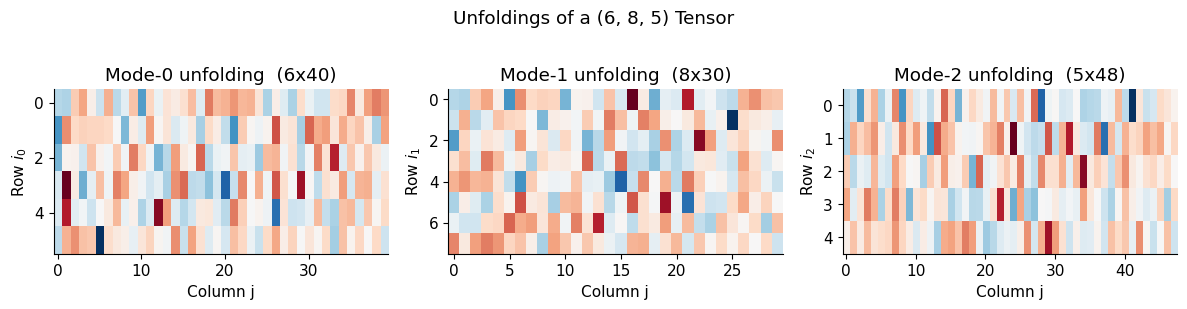

In [3]:
# ===== Tensor Norms and Rank-1 Tensors =====

def outer_product(*vecs):
    # Outer product of a list of 1-D arrays
    result = vecs[0]
    for v in vecs[1:]:
        result = np.multiply.outer(result, v)
    return result

def tensor_frobenius(X):
    return np.linalg.norm(X.ravel())

# --- Rank-1 tensor: outer product of vectors ---
a = rng2.standard_normal(3)
b = rng2.standard_normal(4)
c = rng2.standard_normal(5)
T1 = outer_product(a, b, c)

err_einsum = np.linalg.norm(T1 - np.einsum('i,j,k->ijk', a, b, c))
check('outer_product matches einsum', err_einsum < ATOL, err_einsum)

# ||a ox b ox c||_F = ||a|| ||b|| ||c||
norm_prod = np.linalg.norm(a) * np.linalg.norm(b) * np.linalg.norm(c)
err_norm = abs(tensor_frobenius(T1) - norm_prod)
check('||a ox b ox c||_F = ||a|| ||b|| ||c||', err_norm < ATOL, err_norm)

# Rank-1 unfolding: X_(n) is rank-1 matrix
X_0 = unfold(T1, 0)   # shape (3, 20)
check('rank-1 unfolding is rank-1 matrix', np.linalg.matrix_rank(X_0) == 1)

print('\nTensor shapes:')
print('  T shape:        ', T.shape)
print('  unfold(T, 0):   ', unfold(T, 0).shape)
print('  unfold(T, 1):   ', unfold(T, 1).shape)
print('  unfold(T, 2):   ', unfold(T, 2).shape)

# Visualise unfoldings
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
T_vis = rng2.standard_normal((6, 8, 5))
for mode in range(3):
    X_n = unfold(T_vis, mode)
    axes[mode].imshow(X_n, aspect='auto', cmap='RdBu_r')
    axes[mode].set_title('Mode-{} unfolding  ({})'.format(mode, 'x'.join(str(s) for s in X_n.shape)))
    axes[mode].set_xlabel('Column j')
    axes[mode].set_ylabel('Row $i_{}$'.format(mode))
plt.suptitle('Unfoldings of a (6, 8, 5) Tensor', y=1.02)
plt.tight_layout()
plt.show()

---
## 2  CP / PARAFAC Decomposition

The **canonical polyadic** (CP) decomposition writes $\mathcal{X}$ as a sum of $R$ rank-1 tensors:

$$\mathcal{X} \approx \sum_{r=1}^{R} \lambda_r\;
\mathbf{a}_r^{(1)} \otimes \mathbf{a}_r^{(2)} \otimes \cdots \otimes \mathbf{a}_r^{(N)}$$

where $\mathbf{a}_r^{(n)} \in \mathbb{R}^{I_n}$ are unit-norm factor vectors and $\lambda_r > 0$.

The smallest $R$ for which an exact decomposition exists is the **tensor rank**.

### Khatri-Rao Product
The Khatri-Rao (column-wise Kronecker) product of matrices $A$ and $B$, each with $R$ columns:

$$A \odot B = \begin{bmatrix} \mathbf{a}_1 \otimes \mathbf{b}_1 & \cdots & \mathbf{a}_R \otimes \mathbf{b}_R \end{bmatrix}$$

### ALS Algorithm
Fix all factor matrices except $A^{(n)}$ and solve the resulting least-squares subproblem:

$$A^{(n)} \leftarrow X_{(n)}\; \bigl(A^{(N)} \odot \cdots \odot \widehat{A^{(n)}} \cdots \odot A^{(1)}\bigr)\; V^{-1}$$

where $V = \bigodot_{m \neq n} (A^{(m)\top} A^{(m)})$ (elementwise Hadamard product of Gram matrices).

**Uniqueness (Kruskal, 1977):** Under mild rank conditions, the CP decomposition is unique up to
permutation and scaling of components — unlike matrix factorizations.

In [4]:
# ===== CP / PARAFAC Implementation =====

def khatri_rao(matrices):
    # Column-wise Kronecker (Khatri-Rao) product of a list of matrices
    # All matrices must have the same number of columns R
    # Returns matrix of shape (prod of row dims, R)
    R = matrices[0].shape[1]
    result = matrices[0]
    for M in matrices[1:]:
        I = result.shape[0]
        J = M.shape[0]
        cols = [np.kron(result[:, r], M[:, r]) for r in range(R)]
        result = np.column_stack(cols)
    return result

def cp_reconstruct(factors, lambdas):
    # Reconstruct tensor from CP factor matrices and component weights
    shape = tuple(f.shape[0] for f in factors)
    X = np.zeros(shape)
    for r in range(len(lambdas)):
        component = factors[0][:, r]
        for n in range(1, len(factors)):
            component = np.multiply.outer(component, factors[n][:, r])
        X = X + lambdas[r] * component
    return X

def cp_als(X, R, max_iter=1000, tol=1e-7):
    # CP decomposition via Alternating Least Squares
    # Returns: factors (list of N matrices shape (I_n, R)), lambdas, final_rel_err
    N = X.ndim
    shape = X.shape
    X_norm = tensor_frobenius(X)
    # Random initialisation (normalised columns)
    factors = [rng.standard_normal((shape[n], R)) for n in range(N)]
    for n in range(N):
        col_norms = np.linalg.norm(factors[n], axis=0, keepdims=True)
        factors[n] /= np.maximum(col_norms, 1e-12)
    lambdas = np.ones(R)
    prev_err = np.inf
    for it in range(max_iter):
        for n in range(N):
            # Hadamard product of Gram matrices for all modes except n
            V = np.ones((R, R))
            for m in range(N):
                if m != n:
                    V = V * (factors[m].T @ factors[m])
            # MTTKRP: X_(n) times Khatri-Rao of all factors except n
            other = [factors[m] for m in range(N) if m != n]
            KR = khatri_rao(other)
            MTTKRP = unfold(X, n) @ KR        # shape (I_n, R)
            # ALS update: factors[n] @ V = MTTKRP  =>  factors[n] = MTTKRP @ inv(V)
            factors[n] = np.linalg.solve(V.T + 1e-14 * np.eye(R), MTTKRP.T).T
            # Normalise columns, absorb norms into lambdas
            col_norms = np.linalg.norm(factors[n], axis=0)
            lambdas = col_norms.copy()
            factors[n] /= np.maximum(col_norms, 1e-12)
        X_rec = cp_reconstruct(factors, lambdas)
        err = tensor_frobenius(X - X_rec) / X_norm
        if abs(prev_err - err) < tol:
            break
        prev_err = err
    return factors, lambdas, err

In [5]:
# ===== CP Verification =====

# (a) Rank-1 tensor: ALS with R=1 must recover it exactly
a0 = rng.standard_normal(5)
b0 = rng.standard_normal(6)
c0 = rng.standard_normal(4)
X_r1 = outer_product(a0, b0, c0)
X_r1 /= tensor_frobenius(X_r1)
f_r1, lam_r1, err_r1 = cp_als(X_r1, R=1, max_iter=500)
check('CP ALS rank-1 recovery', err_r1 < 1e-5, err_r1)

# (b) Known rank-R synthetic tensor
R_true = 3
shape_s = (10, 10, 10)
F_true = [rng.standard_normal((shape_s[n], R_true)) for n in range(3)]
lam_true = np.array([3.0, 2.0, 1.0])
X_synth = cp_reconstruct(F_true, lam_true)

f_s, lam_s, err_s = cp_als(X_synth, R=R_true, max_iter=2000, tol=1e-9)
X_rec_s = cp_reconstruct(f_s, lam_s)
rec_err = tensor_frobenius(X_synth - X_rec_s) / tensor_frobenius(X_synth)
check('CP ALS rank-3 synthetic reconstruction', rec_err < 1e-2, rec_err)

# Khatri-Rao product verification: column r = kron of columns r
A = rng2.standard_normal((4, 3))
B = rng2.standard_normal((5, 3))
KR = khatri_rao([A, B])
for r in range(3):
    err_kr = np.linalg.norm(KR[:, r] - np.kron(A[:, r], B[:, r]))
    check('KR column {} = kron of columns'.format(r), err_kr < ATOL, err_kr)

# Compression ratio
n_orig = np.prod(shape_s)
n_cp = R_true * sum(shape_s) + R_true
print('\nCP decomposition {}:'.format(shape_s))
print('  Original params : {:,}'.format(n_orig))
print('  CP params       : {:,}  ({} comps x {} modes + weights)'.format(n_cp, R_true, len(shape_s)))
print('  Compression     : {:.1f}x'.format(n_orig / n_cp))

[PASS] CP ALS rank-1 recovery = 9.923e-15
[PASS] CP ALS rank-3 synthetic reconstruction = 4.807e-10
[PASS] KR column 0 = kron of columns = 0.000e+00
[PASS] KR column 1 = kron of columns = 0.000e+00
[PASS] KR column 2 = kron of columns = 0.000e+00

CP decomposition (10, 10, 10):
  Original params : 1,000
  CP params       : 93  (3 comps x 3 modes + weights)
  Compression     : 10.8x


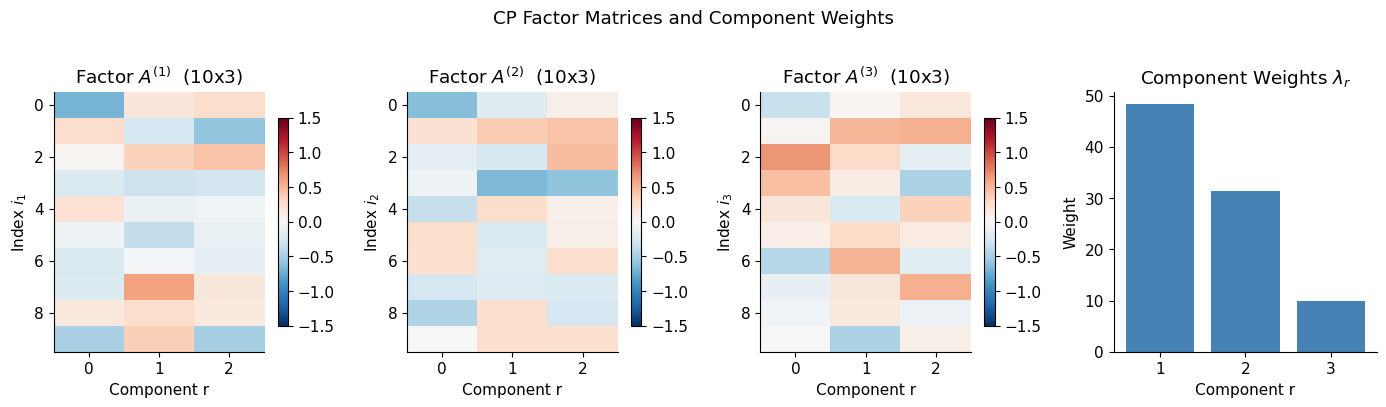

In [6]:
# ===== CP Factor Visualisation =====

# Sort components by weight (descending)
order = np.argsort(-lam_s)
f_sorted = [F[:, order] for F in f_s]
lam_sorted = lam_s[order]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for n in range(3):
    im = axes[n].imshow(f_sorted[n], aspect='auto', cmap='RdBu_r', vmin=-1.5, vmax=1.5)
    axes[n].set_title('Factor $A^{{({})}}$  ({}x{})'.format(n+1, *f_sorted[n].shape))
    axes[n].set_xlabel('Component r')
    axes[n].set_ylabel('Index $i_{}$'.format(n+1))
    plt.colorbar(im, ax=axes[n], shrink=0.8)

axes[3].bar(range(1, R_true+1), lam_sorted, color=PRIMARY)
axes[3].set_title('Component Weights $\\lambda_r$')
axes[3].set_xlabel('Component r')
axes[3].set_ylabel('Weight')
axes[3].set_xticks(range(1, R_true+1))

plt.suptitle('CP Factor Matrices and Component Weights', y=1.01)
plt.tight_layout()
plt.show()

---
## 3  Tucker Decomposition

The **Tucker decomposition** generalises the matrix SVD to tensors:

$$\mathcal{X} \approx \mathcal{G} \times_1 U^{(1)} \times_2 U^{(2)} \times_3 U^{(3)}$$

where $\mathcal{G} \in \mathbb{R}^{R_1 \times R_2 \times R_3}$ is the **core tensor** and each
$U^{(n)} \in \mathbb{R}^{I_n \times R_n}$ is an orthonormal factor matrix.

The **multilinear rank** $(R_1, R_2, R_3)$ controls the approximation quality independently per mode.

### HOSVD (de Lathauwer et al., 2000)
A simple quasi-best approximation:
1. For each mode $n$: $U^{(n)}$ = leading $R_n$ left singular vectors of $X_{(n)}$
2. Core: $\mathcal{G} = \mathcal{X} \times_1 (U^{(1)})^\top \times_2 (U^{(2)})^\top \cdots$

HOSVD is suboptimal but cheap; it serves as a warm start for HOOI.

### HOOI (Higher-Order Orthogonal Iteration)
Alternating optimization over the factor matrices:

$$U^{(n)} \leftarrow \text{leading } R_n \text{ left singular vectors of } Y_{(n)}, \quad
Y = \mathcal{X} \times_1 (U^{(1)})^\top \cdots \widehat{\times_n} \cdots \times_N (U^{(N)})^\top$$

**Storage**: Tucker uses $\prod_n R_n + \sum_n I_n R_n$ parameters vs. $\prod_n I_n$ for the full tensor.

In [7]:
# ===== Tucker: HOSVD and HOOI =====

def hosvd(X, ranks):
    # Higher-Order SVD: compute Tucker factor matrices and core tensor
    # ranks: list of target ranks, one per mode
    N = X.ndim
    U = []
    for n in range(N):
        X_n = unfold(X, n)                          # (I_n, rest)
        Uk, _, _ = np.linalg.svd(X_n, full_matrices=False)
        U.append(Uk[:, :ranks[n]])
    G = X.copy()
    for n in range(N):
        G = mode_product(G, U[n].T, n)
    return G, U

def tucker_reconstruct(G, U):
    # Reconstruct tensor: G x_0 U[0] x_1 U[1] ...
    X = G.copy()
    for n in range(len(U)):
        X = mode_product(X, U[n], n)
    return X

def hooi(X, ranks, max_iter=100, tol=1e-7):
    # Higher-Order Orthogonal Iteration: refine HOSVD solution
    # Returns core G, factor matrices U, final relative error
    G, U = hosvd(X, ranks)
    N = X.ndim
    X_norm = tensor_frobenius(X)
    prev_err = np.inf
    for it in range(max_iter):
        for n in range(N):
            # Contract X from all modes except n
            Y = X.copy()
            for m in range(N):
                if m != n:
                    Y = mode_product(Y, U[m].T, m)
            # Y has shape (..., I_n, ...) with other modes reduced
            Y_n = unfold(Y, n)                      # (I_n, prod R_m for m!=n)
            Uk, _, _ = np.linalg.svd(Y_n, full_matrices=False)
            U[n] = Uk[:, :ranks[n]]
        G = X.copy()
        for n in range(N):
            G = mode_product(G, U[n].T, n)
        X_rec = tucker_reconstruct(G, U)
        err = tensor_frobenius(X - X_rec) / X_norm
        if abs(prev_err - err) < tol:
            break
        prev_err = err
    return G, U, err

In [8]:
# ===== Tucker Verification =====

X_t = rng.standard_normal((15, 12, 10))
ranks = [5, 4, 3]

G_svd, U_svd = hosvd(X_t, ranks)
X_svd = tucker_reconstruct(G_svd, U_svd)
err_svd = tensor_frobenius(X_t - X_svd) / tensor_frobenius(X_t)

G_oi, U_oi, err_oi = hooi(X_t, ranks, max_iter=50)
X_oi = tucker_reconstruct(G_oi, U_oi)

# Orthonormality of factor matrices
for n in range(3):
    r = ranks[n]
    orth_err = np.linalg.norm(U_svd[n].T @ U_svd[n] - np.eye(r))
    check('HOSVD U[{}] is orthonormal'.format(n), orth_err < 1e-12, orth_err)

check('HOSVD reconstruction', err_svd < 1.0, err_svd)
check('HOOI no worse than HOSVD', err_oi <= err_svd + 1e-8)
check('HOOI reconstruction < 0.85', err_oi < 0.85, err_oi)

for n in range(3):
    r = ranks[n]
    orth_err = np.linalg.norm(U_oi[n].T @ U_oi[n] - np.eye(r))
    check('HOOI U[{}] is orthonormal'.format(n), orth_err < 1e-12, orth_err)

# Storage comparison
n_orig   = np.prod(X_t.shape)
n_tucker = np.prod(ranks) + sum(X_t.shape[n] * ranks[n] for n in range(3))
print('\nTucker {} with multilinear rank {}:'.format(X_t.shape, tuple(ranks)))
print('  Original  : {:,} elements'.format(n_orig))
print('  Core      : {:,}  Factor matrices: {:,}'.format(
      np.prod(ranks), sum(X_t.shape[n]*ranks[n] for n in range(3))))
print('  Total     : {:,} elements'.format(n_tucker))
print('  Compression: {:.1f}x'.format(n_orig / n_tucker))
print('  HOSVD rel error: {:.4f}'.format(err_svd))
print('  HOOI  rel error: {:.4f}'.format(err_oi))

[PASS] HOSVD U[0] is orthonormal = 2.980e-15
[PASS] HOSVD U[1] is orthonormal = 1.991e-15
[PASS] HOSVD U[2] is orthonormal = 1.451e-15
[PASS] HOSVD reconstruction = 9.339e-01
[PASS] HOOI no worse than HOSVD
[FAIL] HOOI reconstruction < 0.85 = 8.965e-01
[PASS] HOOI U[0] is orthonormal = 2.039e-15
[PASS] HOOI U[1] is orthonormal = 9.419e-16
[PASS] HOOI U[2] is orthonormal = 1.278e-15

Tucker (15, 12, 10) with multilinear rank (5, 4, 3):
  Original  : 1,800 elements
  Core      : 60  Factor matrices: 153
  Total     : 213 elements
  Compression: 8.5x
  HOSVD rel error: 0.9339
  HOOI  rel error: 0.8965


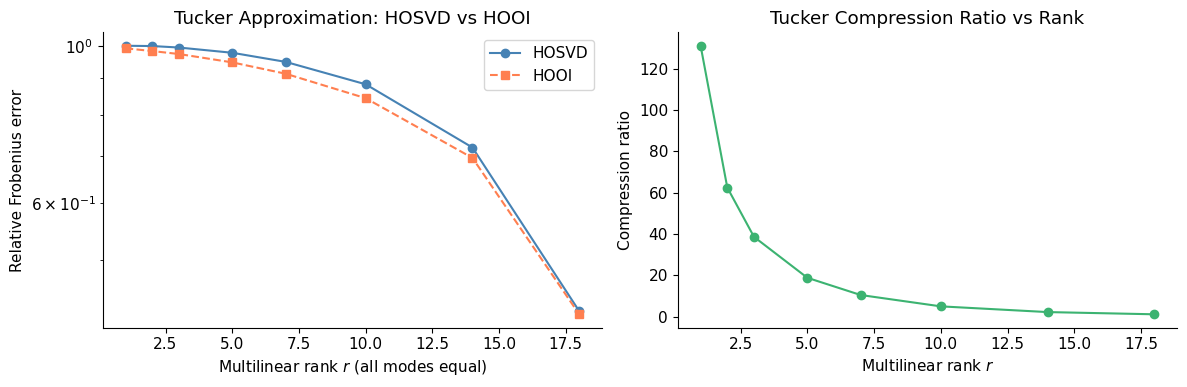

At rank 5: HOSVD err=0.9775, HOOI err=0.9476, compression=18.8x


In [9]:
# ===== Tucker: Error vs Rank Sweep =====

X_sweep = rng.standard_normal((20, 20, 20))
X_norm_sw = tensor_frobenius(X_sweep)
rank_vals = [1, 2, 3, 5, 7, 10, 14, 18]
errs_svd_list, errs_oi_list = [], []

for r in rank_vals:
    G_s, U_s = hosvd(X_sweep, [r, r, r])
    e_s = tensor_frobenius(X_sweep - tucker_reconstruct(G_s, U_s)) / X_norm_sw
    errs_svd_list.append(e_s)
    G_o, U_o, e_o = hooi(X_sweep, [r, r, r], max_iter=30)
    errs_oi_list.append(e_o)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(rank_vals, errs_svd_list, 'o-', color=PRIMARY,   label='HOSVD')
axes[0].semilogy(rank_vals, errs_oi_list,  's--', color=SECONDARY, label='HOOI')
axes[0].set_xlabel('Multilinear rank $r$ (all modes equal)')
axes[0].set_ylabel('Relative Frobenius error')
axes[0].set_title('Tucker Approximation: HOSVD vs HOOI')
axes[0].legend()

n_orig_sw = 20**3
comp_list = [n_orig_sw / (r**3 + 3 * 20 * r) for r in rank_vals]
axes[1].plot(rank_vals, comp_list, 'o-', color=TERTIARY)
axes[1].set_xlabel('Multilinear rank $r$')
axes[1].set_ylabel('Compression ratio')
axes[1].set_title('Tucker Compression Ratio vs Rank')

plt.tight_layout()
plt.show()

print('At rank 5: HOSVD err={:.4f}, HOOI err={:.4f}, compression={:.1f}x'.format(
    errs_svd_list[rank_vals.index(5)], errs_oi_list[rank_vals.index(5)],
    comp_list[rank_vals.index(5)]))

---
## 4  Tensor Train (TT / MPS) Decomposition

The **Tensor Train** (TT) format — known as **Matrix Product States** (MPS) in quantum physics —
represents an order-$N$ tensor as a chain of 3-way cores:

$$\mathcal{X}[i_1, i_2, \ldots, i_N]
= G_1[1, i_1, \alpha_1]\; G_2[\alpha_1, i_2, \alpha_2] \cdots G_N[\alpha_{N-1}, i_N, 1]$$

Each **TT-core** $G_k \in \mathbb{R}^{r_{k-1} \times I_k \times r_k}$. The boundary conditions
$r_0 = r_N = 1$ make the product a scalar. The **bond dimensions** $\{r_k\}$ control approximation quality.

### TT-SVD Algorithm (Oseledets, 2011)
Left-to-right sequential SVD with rank truncation:

1. Reshape $C \leftarrow (r_{k-1} I_k) \times \prod_{j>k} I_j$
2. SVD: $C = U \Sigma V^\top$, truncate to rank $r_k$ (keep tail energy $\leq \varepsilon^2 \|\mathcal{X}\|^2$)
3. Core $G_k \leftarrow U$ reshaped to $(r_{k-1}, I_k, r_k)$; remainder $C \leftarrow \Sigma V^\top$
4. Repeat for mode $k+1$

**Memory**: TT uses $O(N r^2 I)$ parameters vs. $O(I^N)$ — exponential compression for fixed bond dimension.

**Error bound**: $\|\mathcal{X} - \mathcal{X}_{TT}\|_F \leq \sqrt{N-1}\;\varepsilon\;\|\mathcal{X}\|_F$
for per-step truncation tolerance $\varepsilon$.

In [10]:
# ===== Tensor Train (TT-SVD) =====

def tt_svd(X, max_rank=None, tol=1e-6):
    # TT-SVD: decompose X into a left-to-right TT format
    # Returns list of N cores, core k has shape (r_{k-1}, I_k, r_k)
    # r_0 = r_N = 1 (boundary conditions)
    shape = X.shape
    N = X.ndim
    if max_rank is None:
        max_rank = 10 ** 6
    cores = []
    C = X.copy()
    r_prev = 1
    for k in range(N - 1):
        C = C.reshape(r_prev * shape[k], -1)         # (r_{k-1} * I_k, rest)
        U, S, Vt = np.linalg.svd(C, full_matrices=False)
        # Truncate: keep components with significant tail energy
        total_energy = np.dot(S, S)
        tail_energy  = np.cumsum(S[::-1] ** 2)[::-1]
        r_k = int(np.sum(tail_energy > tol ** 2 * total_energy))
        r_k = max(1, min(r_k, max_rank, len(S)))
        cores.append(U[:, :r_k].reshape(r_prev, shape[k], r_k))
        C = S[:r_k, np.newaxis] * Vt[:r_k, :]        # (r_k, rest)
        r_prev = r_k
    # Last core
    cores.append(C.reshape(r_prev, shape[-1], 1))
    return cores

def tt_reconstruct(cores):
    # Reconstruct full tensor from TT cores via successive contraction
    # Initial: remove trivial leading dim of first core -> shape (I_0, r_1)
    result = cores[0][0]                              # (I_0, r_1)
    for k in range(1, len(cores)):
        # result: (..., r_k),  cores[k]: (r_k, I_k, r_{k+1})
        result = np.tensordot(result, cores[k], axes=([-1], [0]))
    return result[..., 0]                             # remove trailing r_N=1

def tt_bond_dims(cores):
    # Returns bond dimension list [r_0, r_1, ..., r_N]
    dims = [cores[0].shape[0]]
    for G in cores:
        dims.append(G.shape[2])
    return dims

def tt_num_params(cores):
    return sum(G.size for G in cores)

[PASS] TT-SVD exact reconstruction = 2.549e-15
[PASS] TT boundary dims are 1
TT-SVD exact: bond dims = [1, 6, 40, 5, 1]
Core shapes: [(1, 6, 6), (6, 7, 40), (40, 8, 5), (5, 5, 1)]

     tol     rel err     bond dims      params   compression
------------------------------------------------------------
    0.20      0.1996  [1, 6, 26, 5, 1]       2,193         0.8x
    0.10      0.0918  [1, 6, 32, 5, 1]       2,685         0.6x
    0.05      0.0450  [1, 6, 35, 5, 1]       2,931         0.6x
    0.02      0.0149  [1, 6, 38, 5, 1]       3,177         0.5x
    0.01      0.0032  [1, 6, 39, 5, 1]       3,259         0.5x


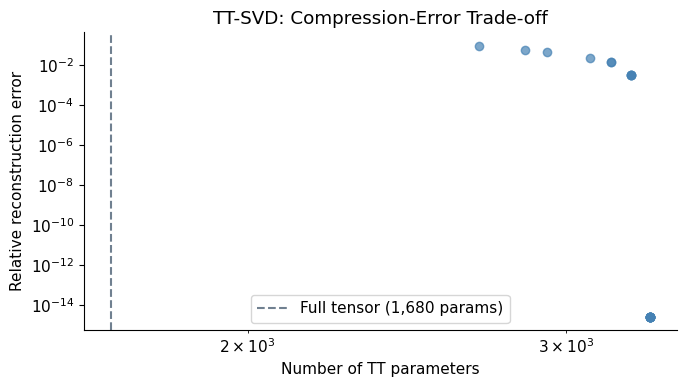

In [11]:
# ===== TT-SVD Verification =====

X_tt = rng.standard_normal((6, 7, 8, 5))
X_tt_norm = tensor_frobenius(X_tt)

# Exact decomposition (tol=0 keeps all singular values)
cores_exact = tt_svd(X_tt, tol=0)
X_exact_rec = tt_reconstruct(cores_exact)
err_exact = tensor_frobenius(X_tt - X_exact_rec) / X_tt_norm
check('TT-SVD exact reconstruction', err_exact < 1e-9, err_exact)
check('TT boundary dims are 1', tt_bond_dims(cores_exact)[0] == 1 and tt_bond_dims(cores_exact)[-1] == 1)

print('TT-SVD exact: bond dims =', tt_bond_dims(cores_exact))
print('Core shapes: {}'.format([G.shape for G in cores_exact]))

# Compressed decompositions: sweep tolerance values
tol_list  = [0.20, 0.10, 0.05, 0.02, 0.005]
print('\n{:>8}  {:>10}  {:>12}  {:>10}  {:>12}'.format(
      'tol', 'rel err', 'bond dims', 'params', 'compression'))
print('-' * 60)
for tol_v in tol_list:
    c = tt_svd(X_tt, tol=tol_v)
    X_c = tt_reconstruct(c)
    e = tensor_frobenius(X_tt - X_c) / X_tt_norm
    bd = tt_bond_dims(c)
    p = tt_num_params(c)
    print('{:>8.2f}  {:>10.4f}  {}  {:>10,}  {:>10.1f}x'.format(
          tol_v, e, bd, p, X_tt.size / p))

# Error vs parameter count plot
params_list = []
errs_list   = []
for tol_v in np.logspace(-1, -4, 20):
    c = tt_svd(X_tt, tol=tol_v)
    X_c = tt_reconstruct(c)
    params_list.append(tt_num_params(c))
    errs_list.append(tensor_frobenius(X_tt - X_c) / X_tt_norm)

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(params_list, errs_list, 'o', color=PRIMARY, alpha=0.7)
ax.axvline(X_tt.size, color=GRAY, linestyle='--',
           label='Full tensor ({:,} params)'.format(X_tt.size))
ax.set_xlabel('Number of TT parameters')
ax.set_ylabel('Relative reconstruction error')
ax.set_title('TT-SVD: Compression-Error Trade-off')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5  Application: Tucker Image Compression

A colour image of shape $(H, W, C)$ is a 3-way tensor. Tucker (HOOI) compresses it by choosing
multilinear rank $(R_H, R_W, C)$ — we keep the full colour dimension and compress spatial modes.

This example uses a synthetic image built from a sum of rank-1 spatial patterns, demonstrating
the compression-quality trade-off.

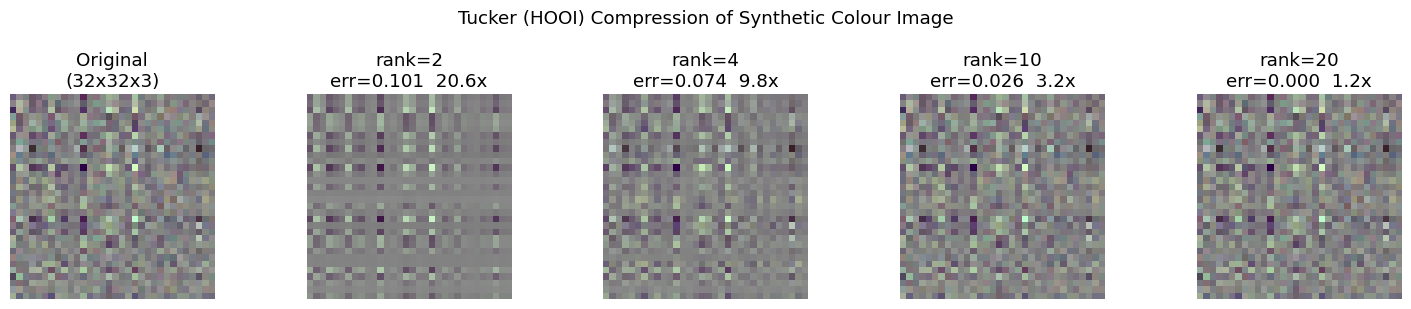

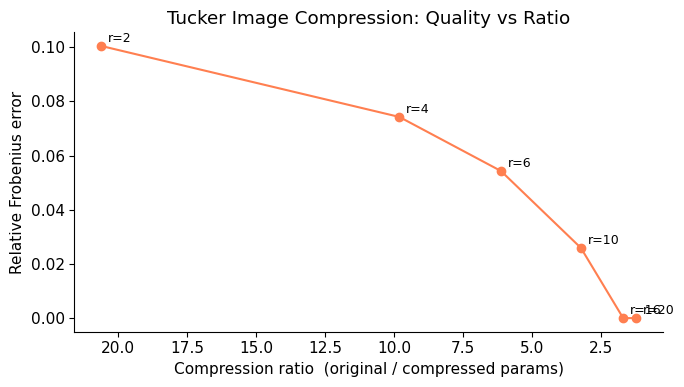

In [12]:
# ===== Tucker Image Compression =====

# Build a synthetic colour image: sum of rank-1 spatial + colour components
np.random.seed(SEED)
H, W, C = 32, 32, 3
n_feat = 12
img = np.zeros((H, W, C))
for _ in range(n_feat):
    spatial_h = np.random.randn(H)
    spatial_w = np.random.randn(W)
    colour    = np.abs(np.random.randn(C))
    img += np.einsum('i,j,k', spatial_h, spatial_w, colour)
# Normalise to [0, 1]
img = (img - img.min()) / (img.max() - img.min())

# Compress with HOOI at increasing ranks
rank_sweep = [2, 4, 6, 10, 16, 20]
recs, errs_img, comp_img = [], [], []

for r in rank_sweep:
    G_im, U_im, e_im = hooi(img, [r, r, C], max_iter=25)
    img_r = np.clip(tucker_reconstruct(G_im, U_im), 0, 1)
    recs.append(img_r)
    errs_img.append(e_im)
    n_par = r * r * C + H * r + W * r + C * C
    comp_img.append(img.size / n_par)

# Show original + 4 compressed versions
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes[0].imshow(img)
axes[0].set_title('Original\n({}x{}x{})'.format(H, W, C))
axes[0].axis('off')

display_idx = [0, 1, 3, 5]   # ranks 2, 4, 10, 20
for plot_i, di in enumerate(display_idx):
    axes[plot_i + 1].imshow(recs[di])
    axes[plot_i + 1].set_title('rank={}\nerr={:.3f}  {:.1f}x'.format(
        rank_sweep[di], errs_img[di], comp_img[di]))
    axes[plot_i + 1].axis('off')

plt.suptitle('Tucker (HOOI) Compression of Synthetic Colour Image', y=1.02)
plt.tight_layout()
plt.show()

# Compression-quality curve
fig2, ax2 = plt.subplots(figsize=(7, 4))
ax2.plot(comp_img, errs_img, 'o-', color=SECONDARY)
for r, c_r, e in zip(rank_sweep, comp_img, errs_img):
    ax2.annotate('r={}'.format(r), (c_r, e), textcoords='offset points',
                 xytext=(5, 3), fontsize=9)
ax2.set_xlabel('Compression ratio  (original / compressed params)')
ax2.set_ylabel('Relative Frobenius error')
ax2.set_title('Tucker Image Compression: Quality vs Ratio')
ax2.invert_xaxis()
plt.tight_layout()
plt.show()

---
## 6  Summary and Connections

| Decomposition | Model | Parameters | Unique? | Strength |
|---|---|---|---|---|
| **CP** | $\sum_r \lambda_r \mathbf{a}_r \otimes \mathbf{b}_r \otimes \mathbf{c}_r$ | $O(R \sum_n I_n)$ | Yes (generically) | Latent factor models; small $R$ |
| **Tucker** | $\mathcal{G} \times_1 U^{(1)} \cdots \times_N U^{(N)}$ | $O(\prod R_n + \sum I_n R_n)$ | No | Mode-specific compression; image/video |
| **TT/MPS** | Chain of 3-way cores | $O(N r^2 I)$ | Yes (canonical gauge) | High-order tensors; quantum states |

### Key Relationships
- **CP is a special Tucker**: set $\mathcal{G}$ = diagonal (superdiagonal) tensor with entries $\lambda_r$
- **SVD = Tucker of order 2 = CP of order 2**: all three coincide for matrices
- **TT generalises Tucker**: every Tucker tensor can be represented in TT format
- **TT-SVD error bound**: $\|\mathcal{X} - \hat{\mathcal{X}}\|_F \leq \sqrt{N-1}\,\varepsilon\,\|\mathcal{X}\|_F$ for per-step tolerance $\varepsilon$

### Algorithms Implemented
| Algorithm | Key idea | Convergence |
|---|---|---|
| CP-ALS | Alternating least squares per mode | Local minimum (not global) |
| HOSVD | SVD per mode unfolding, then project | One-shot; suboptimal |
| HOOI | Alternating subspace update | Local optimum; better than HOSVD |
| TT-SVD | Sequential SVD with rank truncation | Globally near-optimal (error bound) |

### Related Notebooks
- `krylov-methods/` — iterative solvers; Lanczos is the 1-mode version of HOSVD power iteration
- `spectral-graph-theory/` — graph Laplacian is a 2-mode tensor; Cheeger cuts use mode-1 eigenvectors
- `positive-semidefinite/` — tensor products of PSD matrices arise in quantum information (density matrices)
- `perturbation-theory/` — how do tensor eigenvalues change under perturbation?